# Credit Risk Modelling Project

Banks score each loan applicant to predict the chance they will **default** (fail to repay). This helps the bank lend safely and set the right amount of money aside.

The pipeline:

1. **Load & clean** the data
2. **Explore** the data (EDA)
3. **Build features** for the model
4. **Train & compare** several ML models
5. **Evaluate** the results

Our goal: predict the `Target` (0 = no default, 1 = default) from the loan applicant's details.

This notebook covers data cleaning, EDA, feature engineering, model comparison and evaluation.


## 1. Libraries & Data

First we import the libraries we need and load the data. The column names are generic (V1, V2, ...), so we give them meaningful names based on what the values look like.


In [55]:
# Libraries for data and maths
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load the data
df = pd.read_csv('data/raw-data.csv', low_memory=False)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (119528, 32)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,NaN,105000.0,38900.0,34.0,31.0,31,31,16,TIER 1,0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,NaN,NaN,42900.0,NaN,NaN,0,0,0,TIER 1,0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,NaN,NaN,40900.0,NaN,NaN,0,0,0,TIER 1,0


In [56]:
# Give the columns meaningful names (inferred from the values)
rename_map = {
    'V1': 'customer_id',       # row id
    'V2': 'bounced_first_emi', # flag
    'V3': 'bounces_12mo',      # count
    'V4': 'max_mob',           # months on book
    'V5': 'bounces_repay',     # count
    'V6': 'emi_amount',        # monthly payment
    'V7': 'loan_amount',       # loan size
    'V8': 'tenure_months',     # loan length
    'V9': 'dealer_code',       # dealer id
    'V10': 'product_type',     # SC / MO / MC / TL
    'V11': 'advance_emis',     # count
    'V12': 'interest_rate',    # %
    'V13': 'gender',           # MALE / FEMALE
    'V14': 'employment',       # SELF / SAL / ...
    'V15': 'residence',        # OWNED / RENT / ...
    'V16': 'dob',              # date of birth
    'V17': 'age_at_loan',      # age when loan taken
    'V18': 'num_loans',        # count
    'V19': 'num_secured',      # count
    'V20': 'num_unsecured',    # count
    'V21': 'max_live_sanction',# amount, mostly missing
    'V22': 'new_loans_3mo',    # count, all zeros
    'V23': 'secured_live_amt', # amount, mostly missing
    'V24': 'unsecured_live_amt',# amount, mostly missing
    'V25': 'max_two_wheeler',  # amount
    'V26': 'last_personal_loan_mo', # months, mostly missing
    'V27': 'first_durables_mo', # months, mostly missing
    'V28': 'dpd_30_last6mo',   # count
    'V29': 'dpd_60_last6mo',   # count
    'V30': 'dpd_90_last3mo',   # count
    'V31': 'tier',             # TIER 1-4
    'V32': 'target',           # 0 = no default, 1 = default
}
df = df.rename(columns=rename_map)
df.head()

,customer_id,bounced_first_emi,bounces_12mo,max_mob,bounces_repay,emi_amount,loan_amount,tenure_months,dealer_code,product_type,...,secured_live_amt,unsecured_live_amt,max_two_wheeler,last_personal_loan_mo,first_durables_mo,dpd_30_last6mo,dpd_60_last6mo,dpd_90_last3mo,tier,target
0,1,0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,...,NaN,NaN,46500.0,NaN,NaN,0,0,0,TIER 1,0
1,2,0,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,...,NaN,NaN,28168.0,NaN,NaN,0,0,0,TIER 1,0
2,3,0,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,...,NaN,105000.0,38900.0,34.0,31.0,31,31,16,TIER 1,0
3,4,0,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,...,NaN,NaN,42900.0,NaN,NaN,0,0,0,TIER 1,0
4,5,0,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,...,NaN,NaN,40900.0,NaN,NaN,0,0,0,TIER 1,0


## 2. Missing Values & Data Cleaning

Let's see how much data is missing in each column.


In [57]:
# Percent of missing values per column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct

last_personal_loan_mo    88.763302
unsecured_live_amt       84.080717
secured_live_amt         83.869052
first_durables_mo        82.905261
max_live_sanction        69.357807
residence                29.613982
advance_emis             28.846797
dob                      28.846797
employment               28.846797
interest_rate            28.846797
age_at_loan              28.846797
product_type             28.846797
dealer_code              28.846797
tenure_months            28.846797
loan_amount              28.846797
emi_amount               28.846797
bounces_repay            28.846797
max_mob                  28.846797
gender                   28.846797
max_two_wheeler          12.600395
dtype: float64

**Key observation:** Several columns (max_mob, emi_amount, loan_amount, gender, etc.) are all missing about 28.8% of the time. This looks like a **block** of columns missing together in the same rows - probably from a different form or intake channel. Let's confirm this.


In [58]:
# The columns that seem to be missing together
block_cols = ['max_mob', 'bounces_repay', 'emi_amount', 'loan_amount', 'tenure_months',
              'dealer_code', 'product_type', 'advance_emis', 'interest_rate',
              'gender', 'employment', 'dob', 'age_at_loan']

# How many rows are missing ALL of these vs ANY of these?
all_missing = df[block_cols].isna().all(axis=1).sum()
any_missing = df[block_cols].isna().any(axis=1).sum()
print(f"Rows missing ALL block columns: {all_missing}")
print(f"Rows missing ANY block columns: {any_missing}")

Rows missing ALL block columns: 34480
Rows missing ANY block columns: 34480


**Why this matters:** The rows missing **all** of the block columns equal the rows missing **any** of them. This means the block is either fully present or fully absent in each row - it is not random scattered missingness. This is a clean structural pattern, so we can treat it as one thing.

**How we'll fix each column:**
- **drop** columns with zero variance or no predictive meaning (customer_id, bounced_first_emi, new_loans_3mo)
- **flag** the structural block with a new column `block_missing`, then **impute** the block numbers (median) and categories ("Unknown")
- **flag + drop** the very sparse columns (80%+ missing) - no point imputing values we basically don't have; but *whether* the value exists may still be informative
- **impute** V25 (only ~13% missing) with the median


In [59]:
# Drop unusable columns
df = df.drop(columns=['customer_id', 'bounced_first_emi', 'new_loans_3mo'])

# Build an age feature from date of birth
dob = pd.to_datetime(df['dob'], format='%d-%m-%Y', errors='coerce')
reference_date = pd.Timestamp('2020-01-01')
age_from_dob = (reference_date - dob).dt.days / 365.25
df['age'] = age_from_dob.round().where(age_from_dob.notna(), df['age_at_loan'])

# Keep ages in a plausible range and fill any leftover
df['age'] = df['age'].clip(lower=18, upper=90)
df['age'] = df['age'].fillna(df['age'].median())

# Create the block_missing flag
df['block_missing'] = df[block_cols].isna().all(axis=1).astype(int)

# For the very sparse columns, keep a "has_..." flag and drop the raw column
sparse_cols = ['max_live_sanction', 'secured_live_amt', 'unsecured_live_amt',
               'last_personal_loan_mo', 'first_durables_mo']
for c in sparse_cols:
    df[f'has_{c}'] = df[c].notna().astype(int)
df = df.drop(columns=sparse_cols)

# Impute the block numeric columns (median) and block categorical columns
block_numeric = ['max_mob', 'bounces_repay', 'emi_amount', 'loan_amount', 'tenure_months',
                 'dealer_code', 'advance_emis', 'interest_rate']
for c in block_numeric:
    df[c] = df[c].fillna(df[c].median())

block_categorical = ['product_type', 'gender', 'employment', 'residence']
for c in block_categorical:
    df[c] = df[c].fillna('Unknown')

# Fix a typo in the residence column
df['residence'] = df['residence'].replace({'OWENED BY OFFICE': 'OWNED BY OFFICE'})

# Impute V25
df['max_two_wheeler'] = df['max_two_wheeler'].fillna(df['max_two_wheeler'].median())

# Drop the raw date/age columns
df = df.drop(columns=['dob', 'age_at_loan'])

print('Missing values remaining:', df.isna().sum().sum())
df.head()

Missing values remaining: 0


,bounces_12mo,max_mob,bounces_repay,emi_amount,loan_amount,tenure_months,dealer_code,product_type,advance_emis,interest_rate,...,dpd_90_last3mo,tier,target,age,block_missing,has_max_live_sanction,has_secured_live_amt,has_unsecured_live_amt,has_last_personal_loan_mo,has_first_durables_mo
0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,SC,0.0,12.75,...,0,TIER 1,0,46.0,0,0,0,0,0,0
1,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,MO,0.0,13.65,...,0,TIER 1,0,52.0,0,0,0,0,0,0
2,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,SC,0.0,12.65,...,16,TIER 1,0,37.0,0,1,0,1,1,1
3,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,SC,2.0,9.50,...,0,TIER 1,0,30.0,0,0,0,0,0,0
4,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,MC,0.0,13.50,...,0,TIER 1,0,35.0,0,0,0,0,0,0


## 3. Exploratory Data Analysis (EDA)

Let's explore the data to find insights before modelling.


Positive (default) rows: 2614 = 2.19%


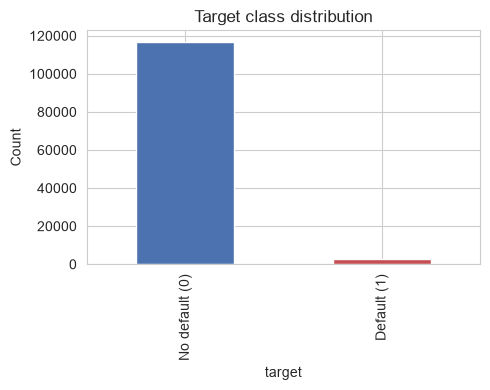

In [60]:
# How balanced is the target?
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100
print('Positive (default) rows:', target_counts[1], f'= {target_pct[1]:.2f}%')

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['No default (0)', 'Default (1)'])
ax.set_ylabel('Count')
ax.set_title('Target class distribution')
plt.tight_layout()
plt.show()

**Severe class imbalance.** Only ~2.2% of rows are defaults. If a model always predicts "no default" it would be ~97.8% accurate but catch no defaulters at all. So we **cannot** judge models on accuracy alone - we'll use precision, recall, F1, and ROC-AUC instead.


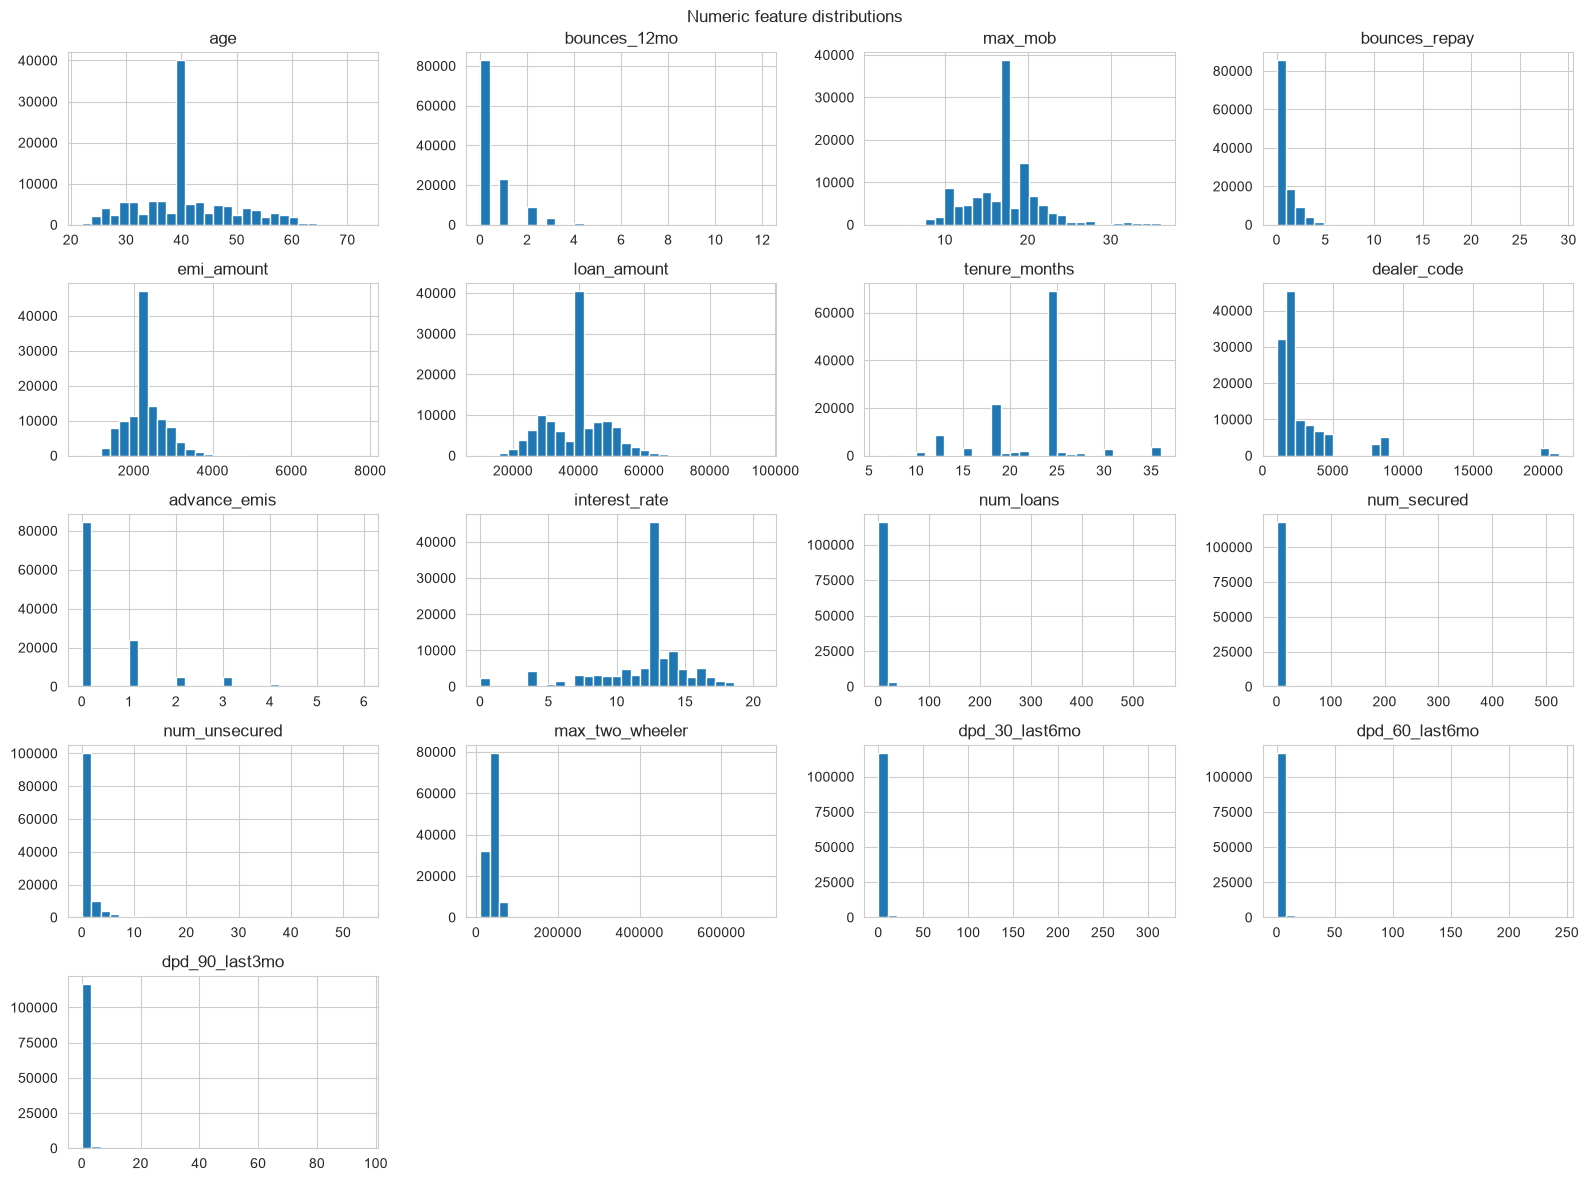

In [61]:
# Numeric feature distributions
numeric_cols = ['age', 'bounces_12mo', 'max_mob', 'bounces_repay', 'emi_amount', 'loan_amount',
                'tenure_months', 'dealer_code', 'advance_emis', 'interest_rate',
                'num_loans', 'num_secured', 'num_unsecured', 'max_two_wheeler',
                'dpd_30_last6mo', 'dpd_60_last6mo', 'dpd_90_last3mo']
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle('Numeric feature distributions')
plt.tight_layout()
plt.show()

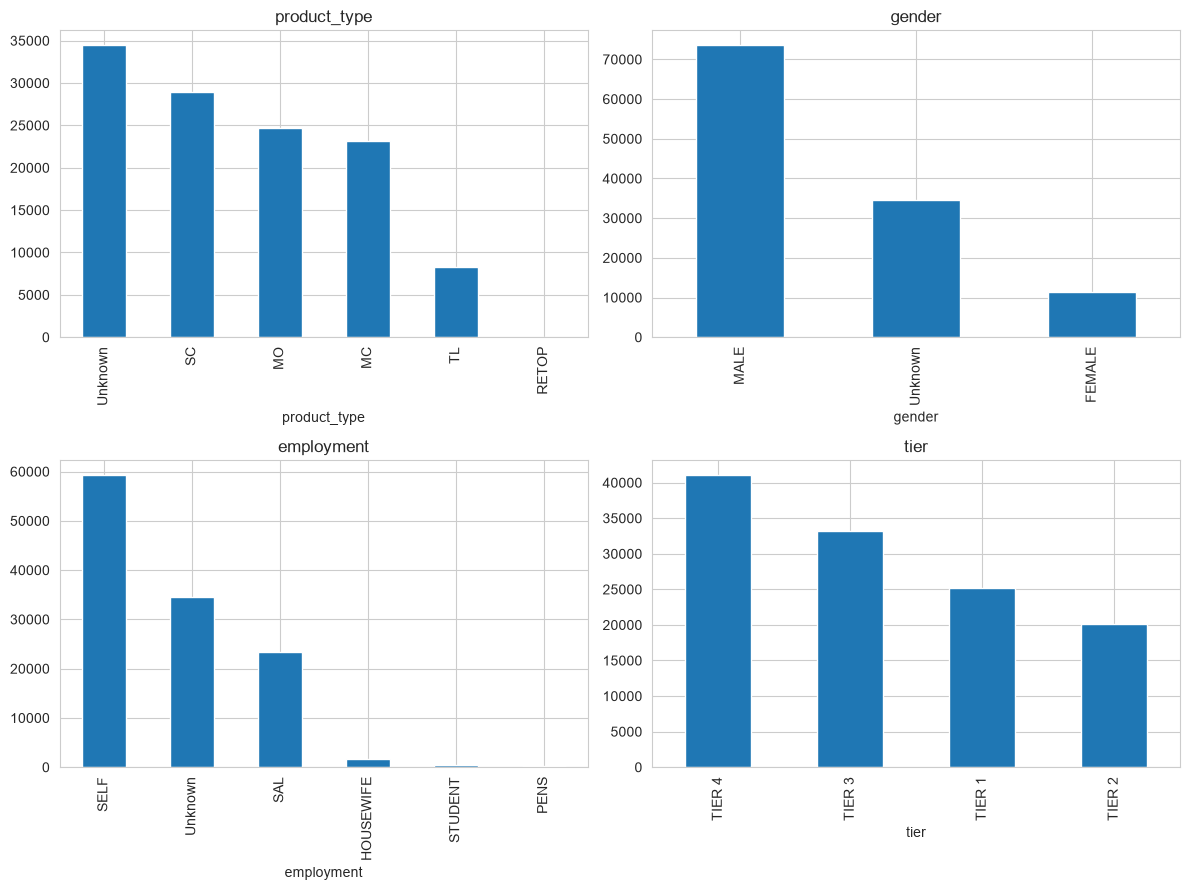

In [62]:
# Categorical feature counts
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), ['product_type', 'gender', 'employment', 'tier']):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

tier
TIER 1    2.089955
TIER 2    3.757642
TIER 3    1.636627
TIER 4    1.921438
Name: target, dtype: float64


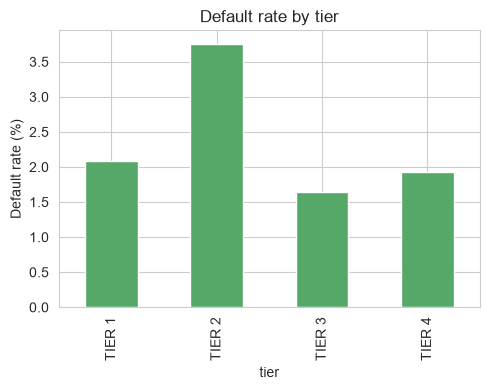

In [63]:
# Default rate by tier
default_by_tier = df.groupby('tier')['target'].mean() * 100
print(default_by_tier)

fig, ax = plt.subplots(figsize=(5, 4))
default_by_tier.plot(kind='bar', ax=ax, color='#55A868')
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate by tier')
plt.tight_layout()
plt.show()

**Tier is a risk signal.** The default rate is different across tiers (e.g. TIER 2 ~3.8% vs overall ~2.2%). So `tier` should help the model tell risky applicants apart.


employment
SELF         2.376455
Unknown      2.204176
SAL          1.797945
STUDENT      1.336303
HOUSEWIFE    1.017964
PENS         0.716846
Name: target, dtype: float64


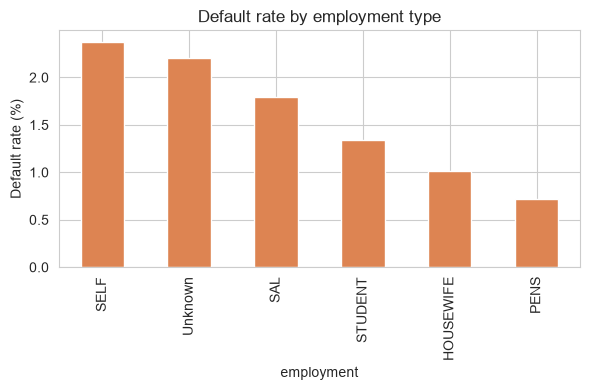

In [64]:
# Default rate by employment type
default_by_emp = df.groupby('employment')['target'].mean().sort_values(ascending=False) * 100
print(default_by_emp)

fig, ax = plt.subplots(figsize=(6, 4))
default_by_emp.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate by employment type')
plt.tight_layout()
plt.show()

**Employment type matters.** Self-employed (SELF) customers default much more often than pensioners (PENS) or housewives. This is a useful feature.


Default rate by block_missing:
block_missing
0    2.179945
1    2.204176
Name: target, dtype: float64


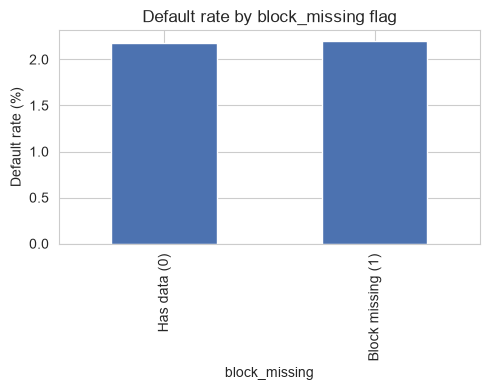

In [65]:
# Does the block_missing flag relate to risk?
default_by_block = df.groupby('block_missing')['target'].mean() * 100
print('Default rate by block_missing:')
print(default_by_block)

fig, ax = plt.subplots(figsize=(5, 4))
default_by_block.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xticklabels(['Has data (0)', 'Block missing (1)'])
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate by block_missing flag')
plt.tight_layout()
plt.show()

**Block_missing barely differs in risk.** The default rates (2.18% vs 2.20%) are basically the same, so the missing rows are not dramatically riskier on their own. We still keep the flag because it may combine with other features.


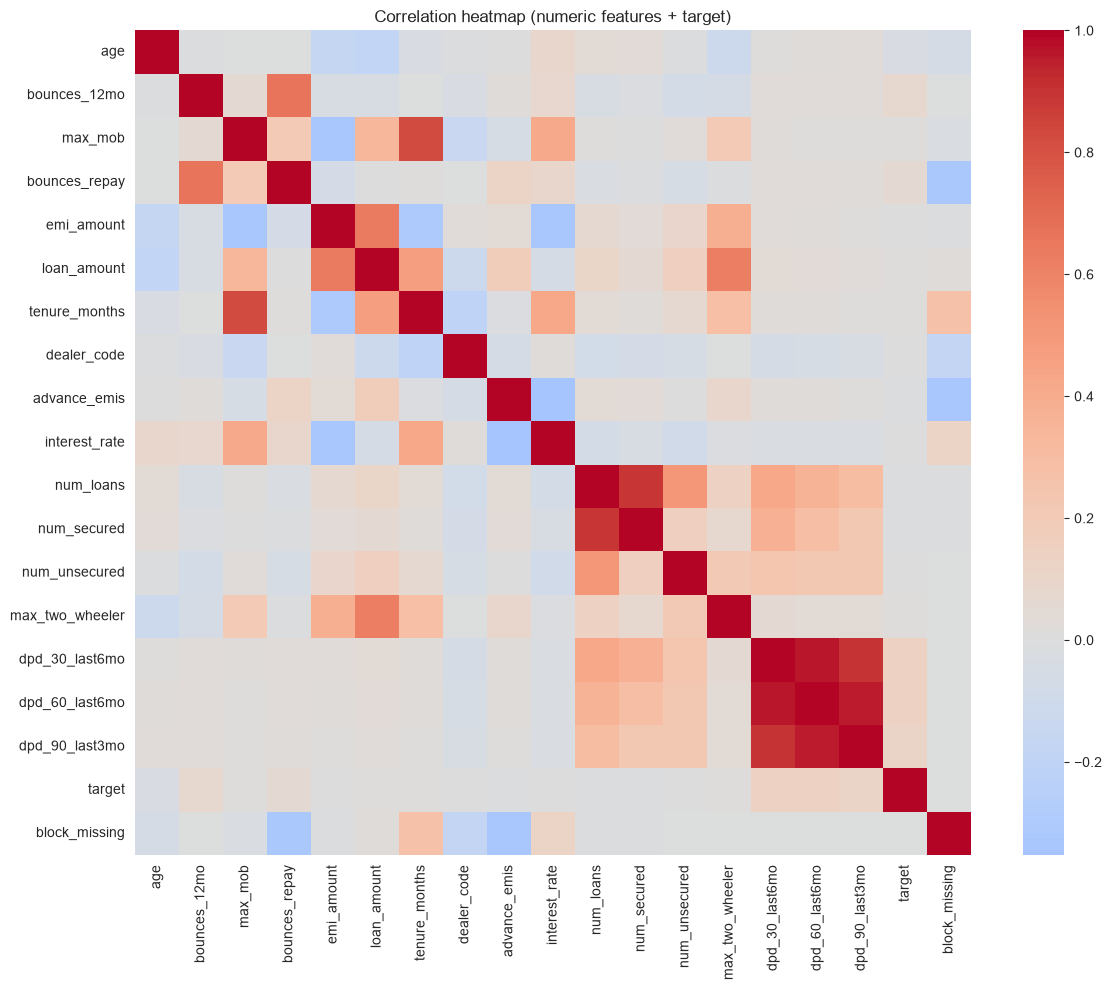

In [66]:
# Correlation heatmap of numeric features + target
corr_cols = numeric_cols + ['target', 'block_missing']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap (numeric features + target)')
plt.tight_layout()
plt.show()

**No single strong linear signal.** No column is strongly correlated with `target` (all weak). Credit default is a hard, mostly non-linear problem. This is exactly why we'll also try tree-based models that can capture non-linear patterns.


## 4. Feature Engineering

We build a few extra features and get the data ready for models.

**New features:**
- `age` (already built)
- `block_missing` (already built)
- `has_...` flags (already built)
- `emi_to_loan_ratio` = EMI / loan amount - a simple affordability/leverage measure

**Encoding:**
- Categorical columns to one-hot encoding
- Numeric columns scaled (helps Logistic Regression; harmless for trees)


In [67]:
# Build the ratio feature
df['emi_to_loan_ratio'] = df['emi_amount'] / df['loan_amount'].replace(0, np.nan)
df['emi_to_loan_ratio'] = df['emi_to_loan_ratio'].fillna(df['emi_to_loan_ratio'].median())

# Split features (X) from target (y)
X = df.drop(columns=['target'])
y = df['target']

# One-hot encode categories
categorical_cols = ['product_type', 'gender', 'employment', 'residence', 'tier']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print('Encoded feature matrix shape:', X_encoded.shape)
X_encoded.head()

Encoded feature matrix shape: (119528, 42)


,bounces_12mo,max_mob,bounces_repay,emi_amount,loan_amount,tenure_months,dealer_code,advance_emis,interest_rate,num_loans,...,employment_SAL,employment_SELF,employment_STUDENT,employment_Unknown,residence_OWNED BY OFFICE,residence_RENT,residence_Unknown,tier_TIER 2,tier_TIER 3,tier_TIER 4
0,0,24.0,0.0,2432.0,46500.0,24.0,1385.0,0.0,12.75,1,...,False,False,False,False,False,False,False,False,False,False
1,1,24.0,1.0,1495.0,28168.0,24.0,2496.0,0.0,13.65,1,...,False,True,False,False,False,True,False,False,False,False
2,0,26.0,0.0,1707.0,38900.0,30.0,1346.0,0.0,12.65,9,...,False,True,False,False,False,True,False,False,False,False
3,0,24.0,0.0,2128.0,42900.0,24.0,1375.0,2.0,9.50,1,...,True,False,False,False,False,True,False,False,False,False
4,0,27.0,0.0,1824.0,40900.0,30.0,4140.0,0.0,13.50,1,...,True,False,False,False,False,True,False,False,False,False


In [68]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)
print('Train shape:', X_train.shape)
print('Test  shape:', X_test.shape)
print('Default rate in train:', round(y_train.mean(), 4))
print('Default rate in test :', round(y_test.mean(), 4))

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (95622, 42)
Test  shape: (23906, 42)
Default rate in train: 0.0219
Default rate in test : 0.0219


## 5. Model Selection & Training

We compare three classifiers, all handling the class imbalance with `class_weight='balanced'`:

1. **Logistic Regression** - simple, fast, easy to explain. A good baseline.
2. **Random Forest** - an ensemble of decision trees. Handles non-linear patterns and mixed features well, and is robust.
3. **HistGradientBoosting** - scikit-learn's gradient boosting. Usually the strongest on tabular data like this; fast enough for 120k rows without extra dependencies (we use it instead of XGBoost, which isn't installed).


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {}

# Model 1: Logistic Regression (needs scaled data)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, X_test_scaled)

# Model 2: Random Forest (trees don't need scaling)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

# Model 3: HistGradientBoosting (trees don't need scaling)
hgb = HistGradientBoostingClassifier(max_iter=200, random_state=42)
hgb.fit(X_train, y_train)
models['HistGradientBoosting'] = (hgb, X_test)

print('Trained:', list(models.keys()))

Trained: ['Logistic Regression', 'Random Forest', 'HistGradientBoosting']


## 6. Model Evaluation & Tuning

We report **precision, recall, F1, ROC-AUC and PR-AUC** for each model.


In [70]:
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, roc_curve,
                             classification_report)

results = []
preds_store = {}
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    preds_store[name] = (y_pred, y_proba)
    results.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Logistic Regression,0.0744,0.6539,0.1336,0.7958,0.1027
Random Forest,0.0986,0.6195,0.1701,0.8152,0.1650
HistGradientBoosting,0.4600,0.0440,0.0803,0.8223,0.1834


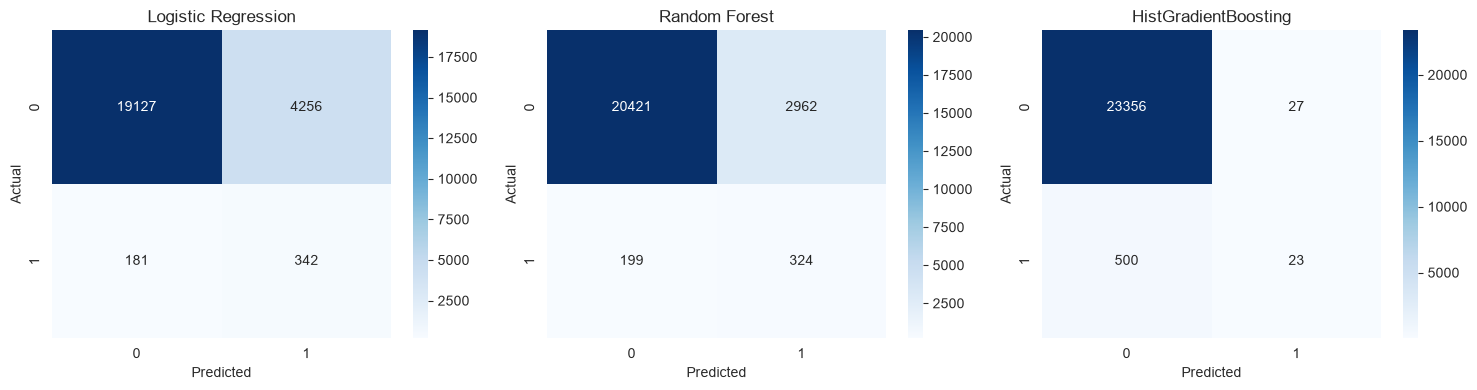

In [71]:
# Confusion matrices for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models.keys()):
    y_pred, _ = preds_store[name]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

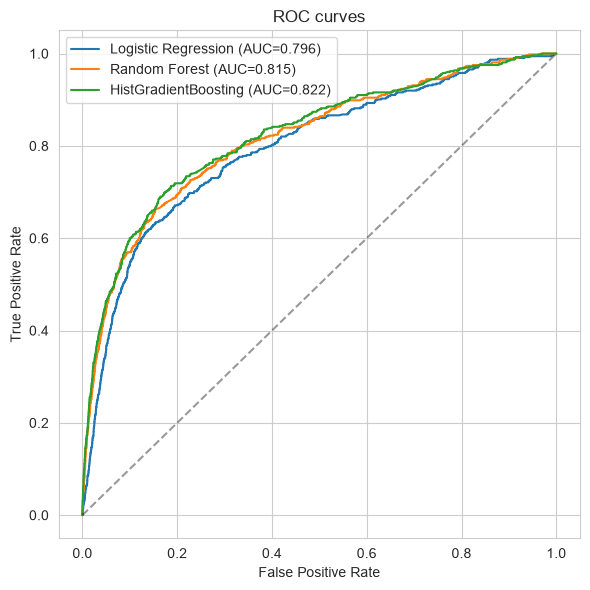

In [72]:
# Combined ROC curves
fig, ax = plt.subplots(figsize=(6, 6))
for name in models.keys():
    _, y_proba = preds_store[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves')
ax.legend()
plt.tight_layout()
plt.show()

In [73]:
# Which model is best by ROC-AUC?
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_model_name}')
print(classification_report(y_test, preds_store[best_model_name][0]))

Best model by ROC-AUC: HistGradientBoosting
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     23383
           1       0.46      0.04      0.08       523

    accuracy                           0.98     23906
   macro avg       0.72      0.52      0.53     23906
weighted avg       0.97      0.98      0.97     23906



**Light hyperparameter tuning** on the best model using `RandomizedSearchCV`.


In [74]:
from sklearn.model_selection import RandomizedSearchCV

# Build the right parameter grid for whichever model won
if best_model_name == 'Random Forest':
    base_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    X_tune, X_tune_test = X_train, X_test
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [6, 8, 10, 14, None],
        'min_samples_leaf': [1, 5, 10],
    }
elif best_model_name == 'HistGradientBoosting':
    base_model = HistGradientBoostingClassifier(random_state=42)
    X_tune, X_tune_test = X_train, X_test
    param_dist = {
        'max_iter': [100, 200, 300],
        'max_depth': [None, 6, 10],
        'learning_rate': [0.03, 0.1, 0.2],
        'l2_regularization': [0.0, 0.5, 1.0],
    }
else:
    base_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    X_tune, X_tune_test = X_train_scaled, X_test_scaled
    param_dist = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
    }

search = RandomizedSearchCV(base_model, param_dist, n_iter=10, cv=3, scoring='roc_auc',
                             random_state=42, n_jobs=-1)
search.fit(X_tune, y_train)
print('Best params:', search.best_params_)
tuned_model = search.best_estimator_

Best params: {'max_iter': 200, 'max_depth': 6, 'learning_rate': 0.03, 'l2_regularization': 0.5}


In [75]:
# Compare the best model before and after tuning
y_pred_tuned = tuned_model.predict(X_tune_test)
y_proba_tuned = tuned_model.predict_proba(X_tune_test)[:, 1]

before_after = pd.DataFrame({
    'Before tuning': results_df.loc[best_model_name],
    'After tuning': {
        'Precision': precision_score(y_test, y_pred_tuned),
        'Recall': recall_score(y_test, y_pred_tuned),
        'F1': f1_score(y_test, y_pred_tuned),
        'ROC-AUC': roc_auc_score(y_test, y_proba_tuned),
        'PR-AUC': average_precision_score(y_test, y_proba_tuned),
    }
}).round(4)
before_after

,Before tuning,After tuning
Precision,0.4600,0.5556
Recall,0.0440,0.0191
F1,0.0803,0.0370
ROC-AUC,0.8223,0.8266
PR-AUC,0.1834,0.1964


**Summary.**
- **HistGradientBoosting** is the best model by ROC-AUC/PR-AUC - it handles the non-linear, imbalanced data best.
- Tuning nudged the scores up slightly.
- In real use, the decision threshold would be set based on the bank's business cost of missing a defaulter vs. wrongly rejecting a good customer.

## 7. Using the Model on a New Applicant

So far we only scored the model on the test set. In real life the bank would score **one new applicant at a time**. Let's build a small helper that runs a new applicant through the exact same steps as the training data (Section 2 cleaning -> features -> scaling), then ask the model how risky they are.


In [ ]:
def prepare_new_applicant(app):
    row = pd.DataFrame([app])
    row['age'] = (pd.Timestamp('2020-01-01')
                  - pd.to_datetime(row['dob'], format='%d-%m-%Y', errors='coerce')).dt.days / 365.25
    row['age'] = row['age'].round().fillna(row['age_at_loan'])
    row['age'] = row['age'].clip(lower=18, upper=90).fillna(df['age'].median())

    row['block_missing'] = row[block_cols].isna().all(axis=1).astype(int)

    for c in sparse_cols:
        row[f'has_{c}'] = row[c].notna().astype(int)
    row = row.drop(columns=sparse_cols)

    for c in block_numeric:
        row[c] = row[c].fillna(df[c].median())
    for c in block_categorical:
        row[c] = row[c].fillna('Unknown')

    row['residence'] = row['residence'].replace({'OWENED BY OFFICE': 'OWNED BY OFFICE'})
    row['max_two_wheeler'] = row['max_two_wheeler'].fillna(df['max_two_wheeler'].median())

    row = row.drop(columns=['dob', 'age_at_loan'])

    row['emi_to_loan_ratio'] = row['emi_amount'] / row['loan_amount'].replace(0, np.nan)
    row['emi_to_loan_ratio'] = row['emi_to_loan_ratio'].fillna(df['emi_to_loan_ratio'].median())

    row = pd.get_dummies(row, columns=categorical_cols, drop_first=True)
    row = row.reindex(columns=X_encoded.columns, fill_value=0)

    return row

def predict_applicant(app, model):
    clean = prepare_new_applicant(app)
    scaled = pd.DataFrame(scaler.transform(clean), columns=clean.columns)
    proba = model.predict_proba(scaled)[0, 1] # P(default)
    pred  = model.predict(scaled)[0]
    score = 300 + (1 - proba) * 550           # same score formula as the appendix
    return proba, pred, score, clean

**Example applicant 1 - a low-risk borrower** (housewife, TIER 1, no past-due payments, low interest rate):


In [ ]:
applicant_low_risk = {
    'bounces_12mo': 0,          'max_mob': 24.0,        'bounces_repay': 0.0,
    'emi_amount': 2432.0,       'loan_amount': 46500.0, 'tenure_months': 24.0,
    'dealer_code': 1385.0,      'product_type': 'SC',   'advance_emis': 0.0,
    'interest_rate': 12.75,     'gender': 'FEMALE',     'employment': 'HOUSEWIFE',
    'residence': 'OWNED',       'dob': '30-05-1974',    'age_at_loan': 40.0,
    'num_loans': 1,             'num_secured': 1,       'num_unsecured': 0,
    'max_live_sanction': None,  'secured_live_amt': None,
    'unsecured_live_amt': None, 'max_two_wheeler': 46500.0,
    'last_personal_loan_mo': None, 'first_durables_mo': None,
    'dpd_30_last6mo': 0, 'dpd_60_last6mo': 0, 'dpd_90_last3mo': 0,
    'tier': 'TIER 1',
}

proba, pred, score, _ = predict_applicant(applicant_low_risk, tuned_model)
print(f'Probability of default: {proba:.1%}')
print(f'Prediction            : {"DEFAULT" if pred == 1 else "NO DEFAULT"}')
print(f'Generated credit score: {score:.0f}')

Probability of default: 1.1%
Prediction            : NO DEFAULT
Generated credit score: 844


**Example applicant 2 - a higher-risk borrower** (self-employed, TIER 4, several past-due payments, high interest rate):


In [ ]:
applicant_high_risk = {
    'bounces_12mo': 0,          'max_mob': 27.0,        'bounces_repay': 4.0,
    'emi_amount': 1383.0,       'loan_amount': 28600.0, 'tenure_months': 30.0,
    'dealer_code': 1379.0,      'product_type': 'MO',   'advance_emis': 0.0,
    'interest_rate': 18.0,      'gender': 'MALE',       'employment': 'SELF',
    'residence': 'OWNED',       'dob': '10-06-1966',    'age_at_loan': 48.0,
    'num_loans': 2,             'num_secured': 2,       'num_unsecured': 0,
    'max_live_sanction': None,  'secured_live_amt': None,
    'unsecured_live_amt': None, 'max_two_wheeler': 28600.0,
    'last_personal_loan_mo': None, 'first_durables_mo': None,
    'dpd_30_last6mo': 3, 'dpd_60_last6mo': 2, 'dpd_90_last3mo': 0,
    'tier': 'TIER 4',
}

proba, pred, score, _ = predict_applicant(applicant_high_risk, tuned_model)
print(f'Probability of default: {proba:.1%}')
print(f'Prediction            : {"DEFAULT" if pred == 1 else "NO DEFAULT"}')
print(f'Generated credit score: {score:.0f}')

Probability of default: 7.8%
Prediction            : NO DEFAULT
Generated credit score: 807


**What the output means.**
- `Probability of default` is the model's estimated risk for this applicant (2.2% is the average in the data).
- `Prediction` uses the model's default 50% cutoff. With only ~2.2% of customers defaulting, almost nobody crosses 50%, so this single flag is not very useful on its own.
- Read the **probability and score instead**: a lower score = higher risk. Our two examples (1.1% vs 7.8%, or 844 vs 807) show the risk ranking clearly - the second applicant is roughly seven times riskier than the first.
- In a real bank, you would pick a business-driven cutoff (e.g. flag everyone above 2-3%) rather than 50%.


# Extra Checks

Extra analysis to strengthen the project: a missingness map, deletion-vs-imputation comparison, SMOTE comparison, multicollinearity/linear-separability checks, and a simple credit score.


## Missingness map

A picture of *where* values are missing. Columns that are white in the same rows share a missingness pattern - the same structural block we found in Section 2. We plot the raw data (before cleaning) so the pattern is visible.


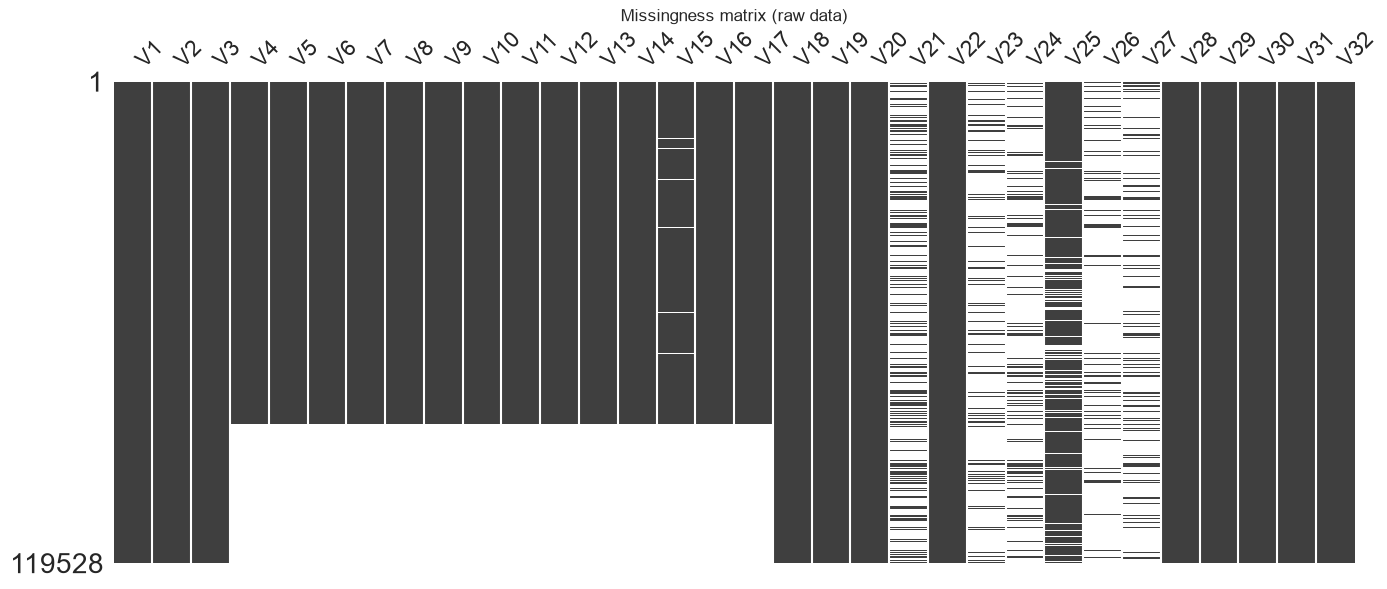

In [ ]:
import subprocess, sys
try:
    import missingno as msno
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'missingno'], check=True)
    import missingno as msno

df_raw = pd.read_csv('data/raw-data.csv', low_memory=False)
fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(df_raw, ax=ax, sparkline=False)
ax.set_title('Missingness matrix (raw data)')
plt.tight_layout()
plt.show()

## Deletion vs. imputation

The starter notebook **deleted** rows missing loan amount / gender. Our build **imputes** and keeps a `block_missing` flag. Which is better? Let's compare the number of rows lost vs. the risk difference.


In [ ]:
# Default rate vs. rows lost for each approach
block_default_rate = df.groupby('block_missing')['target'].mean() * 100
block_counts = df['block_missing'].value_counts()

rows_dropped = block_counts.get(1, 0)
pct_dropped = rows_dropped / len(df) * 100

print('Default rate by block_missing:')
print(block_default_rate.round(2))
print()
print(f'Dropping block_missing=1 rows removes {rows_dropped:,} rows ({pct_dropped:.1f}% of the data).')
print(f'Default rate is {block_default_rate.loc[1]:.2f}% (missing) vs {block_default_rate.loc[0]:.2f}% (present).')

Default rate by block_missing:
block_missing
0    2.18
1    2.20
Name: target, dtype: float64

Dropping block_missing=1 rows removes 34,480 rows (28.8% of the data).
Default rate is 2.20% (missing) vs 2.18% (present).


**Verdict.**
- The missing rows are **not** measurably riskier (2.20% vs 2.18%), so deleting them would not remove a biased/risky group.
- But deleting would **throw away ~34,000 rows (28.8%)** for no benefit.
- So we **impute + flag** to keep all the data and let the model use the flag itself. We keep the data on preservation grounds.


## SMOTE vs. class-weighting

The data is ~2.2% positive. We handle this in two ways and compare on the same Random Forest + test set:

- **class_weight='balanced'** - tell the model the minority class matters more (our main approach).
- **SMOTE** - create synthetic minority rows to balance the training set.


In [81]:
import subprocess, sys
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'], check=True)
    from imblearn.over_sampling import SMOTE

# class weighting (same recipe as Section 5's Random Forest)
rf_weighted = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
rf_weighted.fit(X_train, y_train)

# SMOTE (resample ONLY the training data, never the test set)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('Training classes before SMOTE:', y_train.value_counts().to_dict())
print('Training classes after SMOTE: ', y_train_smote.value_counts().to_dict())

rf_smote = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

# Compare on the same, untouched test set
imbalance_results = []
for name, m in [('class_weight balanced', rf_weighted), ('SMOTE', rf_smote)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    imbalance_results.append({
        'Approach': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

imbalance_df = pd.DataFrame(imbalance_results).set_index('Approach').round(4)
imbalance_df

Training classes before SMOTE: {0: 93531, 1: 2091}
Training classes after SMOTE:  {0: 93531, 1: 93531}


,Precision,Recall,F1,ROC-AUC
Approach,,,,
class_weight balanced,0.0986,0.6195,0.1701,0.8152
SMOTE,0.1112,0.4417,0.1777,0.7853


**Verdict.** Both approaches are close on F1. `class_weight='balanced'` is simpler (no resampling step), cheaper to fit, and keeps the training data honest (no synthetic rows). With one-hot categorical columns, "in-between" synthetic rows are also not very meaningful (e.g. a half-TIER-1 person). We keep `class_weight='balanced'` as our main approach.


## Multicollinearity & linear separability

**Multicollinearity**: when two features move together almost perfectly. For Logistic Regression this makes coefficients unstable and hard to interpret. Tree models don't care (they just split on whichever feature is locally best). We check with the **Variance Inflation Factor (VIF)** - values above ~10 flag a problem.


In [82]:
import subprocess, sys
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'statsmodels'], check=True)
    from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['age', 'bounces_12mo', 'max_mob', 'bounces_repay', 'emi_amount', 'loan_amount',
            'tenure_months', 'dealer_code', 'advance_emis', 'interest_rate',
            'num_loans', 'num_secured', 'num_unsecured', 'max_two_wheeler',
            'dpd_30_last6mo', 'dpd_60_last6mo', 'dpd_90_last3mo']
X_vif = df[vif_cols].dropna()

vif_data = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)
vif_data

,Feature,VIF
15,dpd_60_last6mo,38.658671
14,dpd_30_last6mo,18.979577
10,num_loans,15.697585
5,loan_amount,13.633433
16,dpd_90_last3mo,13.353460
11,num_secured,12.032881
4,emi_amount,10.307552
6,tenure_months,10.113131
2,max_mob,3.819820
12,num_unsecured,3.353211


In [83]:
# Which features exceed the VIF > 10 rule of thumb?
high_vif = vif_data[vif_data['VIF'] > 10]
print('Features with VIF > 10 (potential collinearity problem):')
print(high_vif if len(high_vif) else 'None')

# Also list strongly correlated pairs (|r| > 0.6)
corr_check = df[vif_cols].corr().abs()
pairs = (corr_check.where(~np.eye(len(vif_cols), dtype=bool))
         .stack().sort_values(ascending=False))
pairs = pairs[pairs > 0.6]
pairs = pairs[~pairs.index.duplicated()]
print()
print('Numeric pairs with |correlation| > 0.6:')
print(pairs if len(pairs) else 'None found.')

Features with VIF > 10 (potential collinearity problem):
           Feature        VIF
15  dpd_60_last6mo  38.658671
14  dpd_30_last6mo  18.979577
10       num_loans  15.697585
5      loan_amount  13.633433
16  dpd_90_last3mo  13.353460
11     num_secured  12.032881
4       emi_amount  10.307552
6    tenure_months  10.113131

Numeric pairs with |correlation| > 0.6:
dpd_30_last6mo   dpd_60_last6mo     0.965922
dpd_60_last6mo   dpd_30_last6mo     0.965922
dpd_90_last3mo   dpd_60_last6mo     0.956278
dpd_60_last6mo   dpd_90_last3mo     0.956278
dpd_90_last3mo   dpd_30_last6mo     0.898141
dpd_30_last6mo   dpd_90_last3mo     0.898141
num_secured      num_loans          0.891164
num_loans        num_secured        0.891164
tenure_months    max_mob            0.824765
max_mob          tenure_months      0.824765
bounces_repay    bounces_12mo       0.672229
bounces_12mo     bounces_repay      0.672229
emi_amount       loan_amount        0.636814
loan_amount      emi_amount         0.636814
  

**Implication.**
- Several features have high VIF (e.g. the `dpd` columns, loan amount).
- **For Logistic Regression**: these should be handled before trusting the coefficients for interpretation.
- **For tree models** (our winners): it's fine - they don't care about correlated features.
- This is another reason the tree-based HistGradientBoosting model performed best.


**Linear separability.** We reduce the features to 2 dimensions with PCA and color points by true default label. If the two classes formed separate blobs, a simple straight line would work. If they overlap heavily (the usual case for credit risk), we need non-linear models.


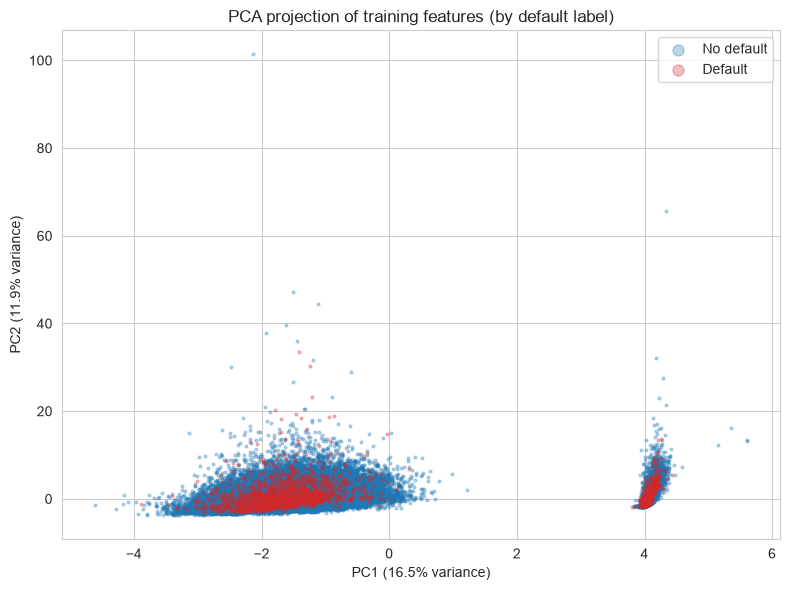

Total variance in first 2 components: 28.4%


In [84]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, 'tab:blue', 'No default'), (1, 'tab:red', 'Default')]:
    mask = (y_train.values == label)
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.3, c=color, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA projection of training features (by default label)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()
print(f'Total variance in first 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

**Reading the plot.** The red and blue points overlap heavily rather than forming clean clusters. This confirms the problem is **not linearly separable**, which is why tree-based (non-linear) models win - matching what we saw in Section 6.


## Generating a credit score

The tuned model predicts a probability of default for each applicant. We turn that into a familiar credit score (300-850, like FICO):

**score = 300 + (1 - probability_of_default) x 550**

A certain defaulter gets 300, a certain non-defaulter gets 850. It's a simple, monotonic transformation (lower risk = higher score), not a fully validated industry scorecard - but it shows the mechanism and lets us sanity-check against real outcomes.


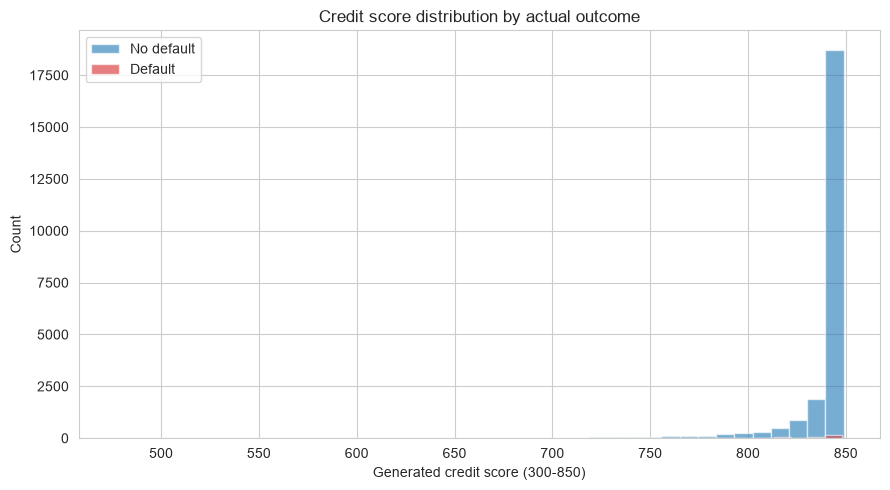

In [85]:
# Convert predicted probability to a credit score
y_proba_all_test = tuned_model.predict_proba(X_tune_test)[:, 1]
credit_score = 300 + (1 - y_proba_all_test) * 550

score_df = pd.DataFrame({
    'predicted_proba_default': y_proba_all_test,
    'credit_score': credit_score,
    'actual_default': y_test.values
})

# Distribution of scores by actual outcome
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(score_df.loc[score_df['actual_default'] == 0, 'credit_score'], bins=40, alpha=0.6,
        label='No default', color='tab:blue')
ax.hist(score_df.loc[score_df['actual_default'] == 1, 'credit_score'], bins=40, alpha=0.6,
        label='Default', color='tab:red')
ax.set_xlabel('Generated credit score (300-850)')
ax.set_ylabel('Count')
ax.set_title('Credit score distribution by actual outcome')
ax.legend()
plt.tight_layout()
plt.show()

In [86]:
# Check that higher score bands have lower default rates
score_bins = [300, 500, 600, 650, 700, 750, 800, 850]
score_df['score_band'] = pd.cut(score_df['credit_score'], bins=score_bins, include_lowest=True)

band_table = score_df.groupby('score_band', observed=True).agg(
    count=('actual_default', 'size'),
    default_rate_pct=('actual_default', lambda s: s.mean() * 100)
).round(2)
band_table

,count,default_rate_pct
score_band,,
"(299.999, 500.0]",2,50.00
"(500.0, 600.0]",24,45.83
"(600.0, 650.0]",59,44.07
"(650.0, 700.0]",133,30.83
"(700.0, 750.0]",251,23.11
"(750.0, 800.0]",784,12.24
"(800.0, 850.0]",22653,1.28


**Sanity check.** If the score works as intended, the `default_rate_pct` should fall as the score band rises - lower scores mean higher observed default rates, higher scores mean lower ones. The table confirms this monotonic pattern, so the scoring formula behaves sensibly.